In [1]:
import xarray as xr
import numpy as np
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pymannkendall as mk
from dask.diagnostics import ProgressBar

In [2]:
# 2008-2020 MetOp-A Data (constant orbit)
# seasonal trends and min and max
# NIGHT and night

In [3]:
# compute monhtly means and stack them
lst_2008 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2008/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [4]:
lst_2009 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2009/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [5]:
lst_2010 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2010/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [6]:
lst_2011 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2011/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [7]:
lst_2012 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2012/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [8]:
lst_2013 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2013/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [9]:
lst_2014 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2014/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [10]:
lst_2015 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2015/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [11]:
lst_2016 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2016/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [12]:
lst_2017 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2017/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [13]:
lst_2018 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2018/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [14]:
lst_2019 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2019/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [15]:
lst_2020 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2020/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*NIGHT.nc', engine='netcdf4')

In [16]:
# load the time series somewhere ?
results = {}

for year in range(2008, 2021):

    ds = globals()[f"lst_{year}"]   # load lst_1981, lst_1982, ...

    clean_LST = ds['LST'].where(ds['LST'] > 110, np.nan)
    monthly_mean = (
        clean_LST
        .resample(
            time='1MS'
        )
        .mean()
    )

    # Ensure bins exist even with no data
    # Xarray automatically creates them and fills with NaN

    results[year] = monthly_mean

combined = xr.concat([results[y] for y in range(2008, 2021)], dim="time")

In [26]:
clim_night = xr.open_dataset('../outputs/combined_monthly_NIGHT_2008_2020_coarse.nc')

In [3]:
clim = xr.open_dataset('../outputs/combined_monthly_day_2008_2020_coarse.nc')

In [5]:
clim

<xarray.Dataset> Size: 2MB
Dimensions:      (lat: 20, lon: 180, time: 156)
Coordinates:
  * lat          (lat) float32 80B 51.0 53.0 55.0 57.0 ... 83.0 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
    band         int64 8B ...
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 1kB 2008-01-01 2008-02-01 ... 2020-12-01
Data variables:
    LST          (lat, lon, time) float32 2MB ...

In [33]:
winter_night = clim_night.sel(time=clim.time.dt.month.isin([1,2, 12]))
winter_night['time']= winter_night['time'] + np.timedelta64(10000000000000000, 'ns')
winter_night_data = winter_night.groupby('time.year').mean()
winter_night_data = winter_night_data.chunk({'year':-1, 'lon':1000, 'lat':100})

In [34]:
winter_night_trends = xr.open_dataset('winter_trend_NIGHT_02deg_coarse.nc')

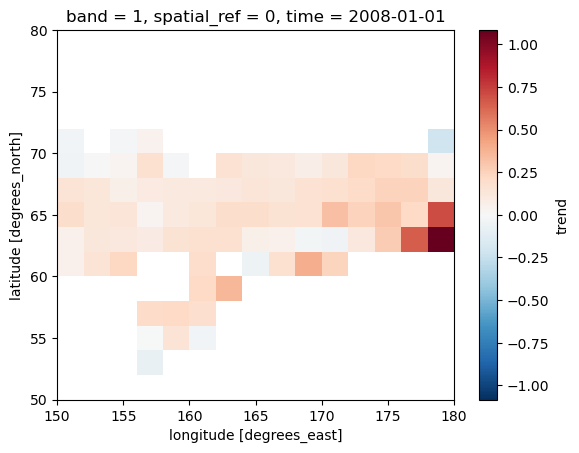

In [35]:
winter_night_trends['trend'].sel(lat=slice(50,80), lon=slice(150,180)).plot();

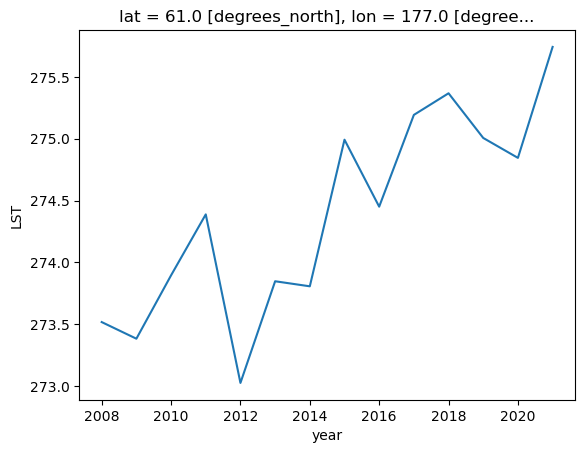

In [39]:
winter_night_data['LST'].sel(lat=60, lon=177, method='nearest').plot();

In [4]:
# compute trends
winter = clim.sel(time=clim.time.dt.month.isin([1,2, 12]))

In [6]:
winter['time']= winter['time'] + np.timedelta64(10000000000000000, 'ns')

In [7]:
winter_data = winter.groupby('time.year').mean()

In [8]:
winter_data = winter_data.chunk({'year':-1, 'lon':1000, 'lat':100})

In [29]:
winter_day_trends = xr.open_dataset('winter_trend_DAY_02deg_coarse.nc')

In [30]:
winter_day_trends

<xarray.Dataset> Size: 30kB
Dimensions:      (lat: 20, lon: 180)
Coordinates:
  * lat          (lat) float32 80B 51.0 53.0 55.0 57.0 ... 83.0 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
    band         int64 8B ...
    spatial_ref  int64 8B ...
    time         datetime64[ns] 8B ...
Data variables:
    trend        (lat, lon) float64 29kB ...

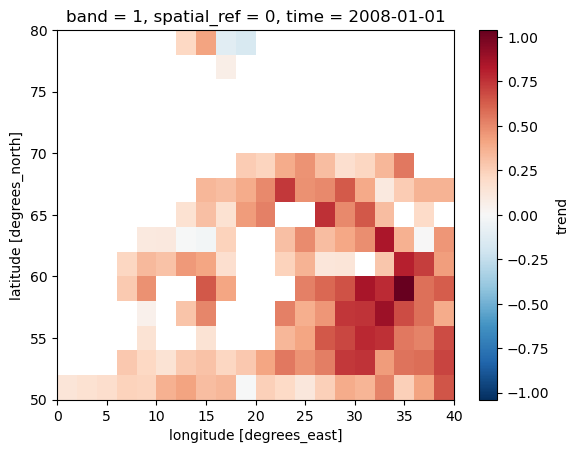

In [31]:
winter_day_trends['trend'].sel(lat=slice(50,80), lon=slice(0,40)).plot();

In [32]:
winter_day_trends['trend'].sel(lat=59, lon=35, method='nearest').values

array(1.03902326)

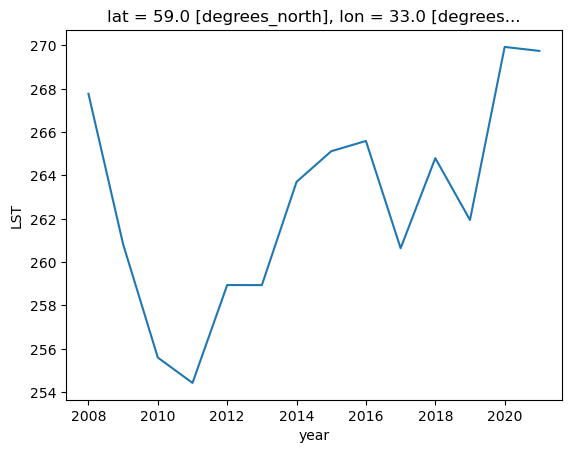

In [24]:
winter_data['LST'].sel(lat=59, lon=33, method='nearest').plot();

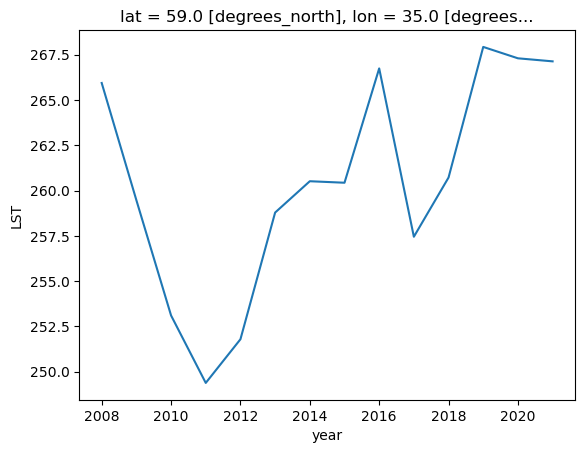

In [20]:
winter_data['LST'].sel(lat=59, lon=35, method='nearest').plot();

In [23]:
winter_data['LST'].sel(lat=59, lon=35, method='nearest').values

array([265.93634, 259.4663 , 253.10489, 249.38173, 251.79202, 258.78482,
       260.5137 , 260.43042, 266.73947, 257.44977, 260.7182 , 267.92627,
       267.29788, 267.1296 ], dtype=float32)

In [ ]:
mk.original_test(Birth_data_holes, alpha=0.05)